In [3]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from collections import Counter
import shutil
from pathlib import Path

from google.colab import drive
drive.mount('/content/drive')

project_dir = "/content/drive/MyDrive/emotion-recognition-classifier"
data_dir = project_dir + "/data"


Mounted at /content/drive


In [4]:

new_train_dir = os.path.join(data_dir, "new_train")
new_val_dir = os.path.join(data_dir, "new_val")
new_test_dir = os.path.join(data_dir, "new_test")


if os.path.exists(new_train_dir) and os.path.exists(new_val_dir):
    print(" Dane już są podzielone! Pomijam podział.")
    print(f"   Train: {new_train_dir}")
    print(f"   Val: {new_val_dir}")
    print(f"   Test: {new_test_dir}")


    classes = sorted(os.listdir(new_train_dir))
    for split_dir, name in [(new_train_dir, "TRAIN"), (new_val_dir, "VAL"), (new_test_dir, "TEST")]:
        print(f"\n{name}:")
        for cls in classes:
            cnt = len(os.listdir(os.path.join(split_dir, cls)))
            print(f"  {cls}: {cnt}")
else:
    print(" Dane nie są podzielone. Uruchom SEKCJĘ 4 aby je podzielić.")

 Dane już są podzielone! Pomijam podział.
   Train: /content/drive/MyDrive/emotion-recognition-classifier/data/new_train
   Val: /content/drive/MyDrive/emotion-recognition-classifier/data/new_val
   Test: /content/drive/MyDrive/emotion-recognition-classifier/data/new_test

TRAIN:
  angry: 0

VAL:
  angry: 0

TEST:
  angry: 0


In [5]:

import os
import shutil
from pathlib import Path

# Ścieżki do oryginalnych danych
original_train_dir = os.path.join(data_dir, "train")
original_test_dir = os.path.join(data_dir, "test")
merged_dir = os.path.join(data_dir, "merged")


if os.path.exists(merged_dir):
    print(" Katalog 'merged' już istnieje!")
    classes = sorted(os.listdir(merged_dir))
    print(f"   Klasy: {classes}")
    for cls in classes:
        cnt = len(os.listdir(os.path.join(merged_dir, cls)))
        print(f"   {cls}: {cnt} obrazów")
else:
    print(" Katalog 'merged' nie istnieje. Tworzę...")

    # Utwórz katalog merged
    os.makedirs(merged_dir, exist_ok=True)

    # Pobierz klasy z train
    classes = sorted(os.listdir(original_train_dir))
    print(f"Klasy: {classes}\n")

    # Dla każdej klasy scal train i test
    for cls in classes:
        print(f" Scalanie klasy: {cls}...", end=" ")

        # Utwórz katalog dla klasy w merged
        merged_cls_dir = os.path.join(merged_dir, cls)
        os.makedirs(merged_cls_dir, exist_ok=True)

        # Pobierz pliki z train i test
        train_cls_dir = os.path.join(original_train_dir, cls)
        test_cls_dir = os.path.join(original_test_dir, cls)

        train_images = os.listdir(train_cls_dir)
        test_images = os.listdir(test_cls_dir) if os.path.exists(test_cls_dir) else []


        count = 0

        # Linkuj z train
        for img in train_images:
            src = os.path.join(train_cls_dir, img)
            dst = os.path.join(merged_cls_dir, img)
            try:
                os.link(src, dst)
                count += 1
            except (FileExistsError, OSError):
                try:
                    os.symlink(src, dst)
                    count += 1
                except FileExistsError:
                    pass


        for img in test_images:
            src = os.path.join(test_cls_dir, img)
            dst = os.path.join(merged_cls_dir, img)
            try:
                os.link(src, dst)
                count += 1
            except (FileExistsError, OSError):
                try:
                    os.symlink(src, dst)
                    count += 1
                except FileExistsError:
                    pass

        print(f"✓ ({len(train_images)} + {len(test_images)} = {count} obrazów)")

    print("\n Scalenie zakończone!")
    print(f"Katalog merged: {merged_dir}")

    # Pokaż statystyki
    print("\nSTATYSTYKI MERGED:")
    total = 0
    for cls in classes:
        cnt = len(os.listdir(os.path.join(merged_dir, cls)))
        total += cnt
        print(f"   {cls}: {cnt}")
    print(f"   TOTAL: {total}")

 Katalog 'merged' już istnieje!
   Klasy: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
   angry: 4953 obrazów
   disgust: 547 obrazów
   fear: 5121 obrazów
   happy: 9002 obrazów
   neutral: 6198 obrazów
   sad: 6077 obrazów
   surprise: 4002 obrazów


In [6]:


from sklearn.model_selection import train_test_split
import os
from pathlib import Path

merged_dir = os.path.join(data_dir, "merged")
classes = sorted(os.listdir(merged_dir))


new_train_dir = "/content/new_train"
new_val_dir = "/content/new_val"
new_test_dir = "/content/new_test"

print(" Rozpoczynam podział danych...")
print(" Używam lokalnej pamięci /content (szybkie!)\n")

import shutil
for d in [new_train_dir, new_val_dir, new_test_dir]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)


def link_files(images_list, cls_dir, target_dir, cls):
    target_cls_dir = os.path.join(target_dir, cls)
    os.makedirs(target_cls_dir, exist_ok=True)

    for img in images_list:
        src = os.path.join(cls_dir, img)
        dst = os.path.join(target_cls_dir, img)
        try:
            os.symlink(src, dst)
        except FileExistsError:
            pass


for cls in classes:
    print(f" {cls}...", end=" ", flush=True)

    cls_dir = os.path.join(merged_dir, cls)
    images = os.listdir(cls_dir)


    train_imgs, temp = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.50, random_state=42)


    link_files(train_imgs, cls_dir, new_train_dir, cls)
    link_files(val_imgs, cls_dir, new_val_dir, cls)
    link_files(test_imgs, cls_dir, new_test_dir, cls)

    print(f"✓ (train:{len(train_imgs)}, val:{len(val_imgs)}, test:{len(test_imgs)})")

print(f" Train: {new_train_dir}")
print(f" Val: {new_val_dir}")
print(f" Test: {new_test_dir}")


print("\n STATYSTYKI:")
for split_dir, name in [(new_train_dir, "TRAIN"), (new_val_dir, "VAL"), (new_test_dir, "TEST")]:
    total = 0
    print(f"\n{name}:")
    for cls in classes:
        cnt = len(os.listdir(os.path.join(split_dir, cls)))
        total += cnt
        print(f"  {cls}: {cnt}")
    print(f"  TOTAL: {total}")


 Rozpoczynam podział danych...
 Używam lokalnej pamięci /content (szybkie!)

 angry... ✓ (train:3467, val:743, test:743)
 disgust... ✓ (train:382, val:82, test:83)
 fear... ✓ (train:3584, val:768, test:769)
 happy... ✓ (train:6301, val:1350, test:1351)
 neutral... ✓ (train:4338, val:930, test:930)
 sad... ✓ (train:4253, val:912, test:912)
 surprise... ✓ (train:2801, val:600, test:601)
 Train: /content/new_train
 Val: /content/new_val
 Test: /content/new_test

 STATYSTYKI:

TRAIN:
  angry: 3467
  disgust: 382
  fear: 3584
  happy: 6301
  neutral: 4338
  sad: 4253
  surprise: 2801
  TOTAL: 25126

VAL:
  angry: 743
  disgust: 82
  fear: 768
  happy: 1350
  neutral: 930
  sad: 912
  surprise: 600
  TOTAL: 5385

TEST:
  angry: 743
  disgust: 83
  fear: 769
  happy: 1351
  neutral: 930
  sad: 912
  surprise: 601
  TOTAL: 5389


In [7]:
# ⚠️ URUCHOM TO TYLKO RAZ! Potem zakomentuj.

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

disgust_dir = os.path.join(new_train_dir, "disgust")
existing_images = os.listdir(disgust_dir)
current_count = len(existing_images)
target_count = 4000

print(f"Obecna liczba obrazów DISGUST: {current_count}")

if current_count >= target_count:
    print("✅ DISGUST już jest zaugmentowany!")
else:
    print(f"Augmentuję do {target_count} obrazów...")

    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )

    i = 0
    while current_count + i < target_count:
        img_name = existing_images[i % len(existing_images)]
        img_path = os.path.join(disgust_dir, img_name)

        img = load_img(img_path, color_mode="grayscale")
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        prefix = f"aug_{i}"
        for batch in datagen.flow(x, batch_size=1,
                                  save_to_dir=disgust_dir,
                                  save_prefix=prefix,
                                  save_format="jpg"):
            break

        i += 1
        if i % 100 == 0:
            print(f"  Wygenerowano: {i}/{target_count - current_count}")

    print(f"✅ Nowa liczba DISGUST: {len(os.listdir(disgust_dir))}")


Obecna liczba obrazów DISGUST: 382
Augmentuję do 4000 obrazów...
  Wygenerowano: 100/3618
  Wygenerowano: 200/3618
  Wygenerowano: 300/3618
  Wygenerowano: 400/3618
  Wygenerowano: 500/3618
  Wygenerowano: 600/3618
  Wygenerowano: 700/3618
  Wygenerowano: 800/3618
  Wygenerowano: 900/3618
  Wygenerowano: 1000/3618
  Wygenerowano: 1100/3618
  Wygenerowano: 1200/3618
  Wygenerowano: 1300/3618
  Wygenerowano: 1400/3618
  Wygenerowano: 1500/3618
  Wygenerowano: 1600/3618
  Wygenerowano: 1700/3618
  Wygenerowano: 1800/3618
  Wygenerowano: 1900/3618
  Wygenerowano: 2000/3618
  Wygenerowano: 2100/3618
  Wygenerowano: 2200/3618
  Wygenerowano: 2300/3618
  Wygenerowano: 2400/3618
  Wygenerowano: 2500/3618
  Wygenerowano: 2600/3618
  Wygenerowano: 2700/3618
  Wygenerowano: 2800/3618
  Wygenerowano: 2900/3618
  Wygenerowano: 3000/3618
  Wygenerowano: 3100/3618
  Wygenerowano: 3200/3618
  Wygenerowano: 3300/3618
  Wygenerowano: 3400/3618
  Wygenerowano: 3500/3618
  Wygenerowano: 3600/3618
✅ Nowa l

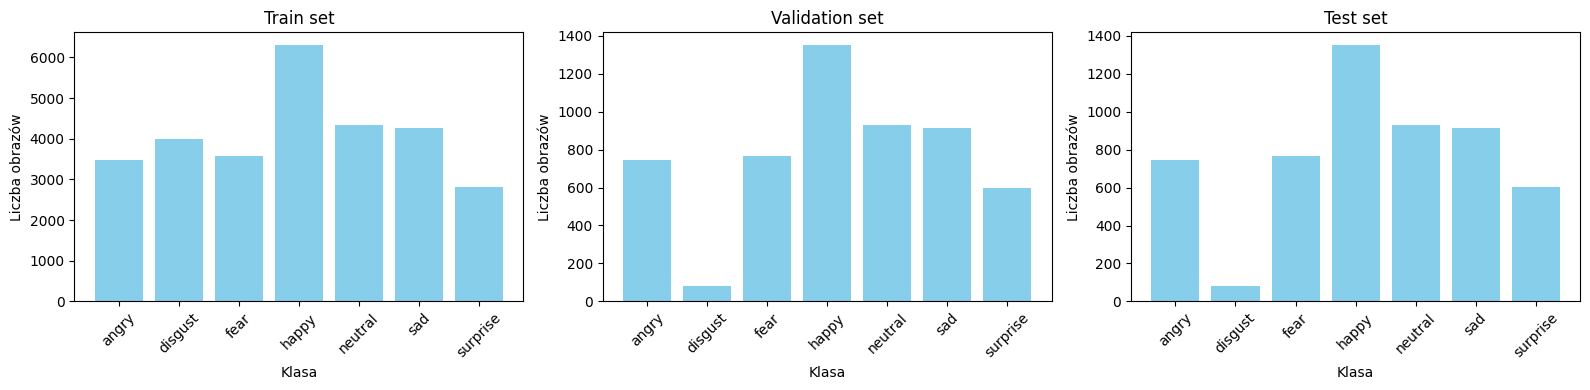

In [8]:


splits = {
    "Train": new_train_dir,
    "Validation": new_val_dir,
    "Test": new_test_dir
}

def count_images(split_dir):
    classes = sorted(os.listdir(split_dir))
    counts = [len(os.listdir(os.path.join(split_dir, cls))) for cls in classes]
    return classes, counts

plt.figure(figsize=(16, 4))

for i, (name, path) in enumerate(splits.items(), 1):
    classes, counts = count_images(path)
    plt.subplot(1, 3, i)
    plt.bar(classes, counts, color='skyblue')
    plt.title(f"{name} set")
    plt.xlabel("Klasa")
    plt.ylabel("Liczba obrazów")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [9]:


balanced_train_dir = Path("/content") / "balanced_train"

def balance_train_only(source_dir, target_dir):
    source_dir = Path(source_dir)
    target_dir = Path(target_dir)


    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

    classes = sorted([d.name for d in source_dir.iterdir() if d.is_dir()])

    # Zliczane pliki w każdej klasie
    class_files = {}
    for cls in classes:
        files = list((source_dir / cls).glob("*.*"))
        class_files[cls] = files
        print(f"{cls}: {len(files)} obrazów")

    # Znajdowanie najmniejszej klasy
    min_count = min(len(files) for files in class_files.values())
    print(f"\n→ Balansuję do {min_count} obrazów na klasę\n")

    # Dla każdej klasy min_count obrazów
    for cls in classes:
        out_dir = target_dir / cls
        out_dir.mkdir(parents=True)

        selected = np.random.choice(class_files[cls], size=min_count, replace=False)


        for f in selected:
            dst = out_dir / f.name
            os.symlink(f, dst)

        print(f"✓ {cls}: {min_count}")

    return target_dir

# Balansowanie train
balanced_train_dir = balance_train_only(new_train_dir, balanced_train_dir)
print(f"\n Zapisano: {balanced_train_dir}")

angry: 3467 obrazów
disgust: 4000 obrazów
fear: 3584 obrazów
happy: 6301 obrazów
neutral: 4338 obrazów
sad: 4253 obrazów
surprise: 2801 obrazów

→ Balansuję do 2801 obrazów na klasę

✓ angry: 2801
✓ disgust: 2801
✓ fear: 2801
✓ happy: 2801
✓ neutral: 2801
✓ sad: 2801
✓ surprise: 2801

 Zapisano: /content/balanced_train


In [10]:

import numpy as np
import shutil
from pathlib import Path
import os

def create_smaller_subset(source_dir, target_dir, samples_per_class=50):
    source_dir = Path(source_dir)
    target_dir = Path(target_dir)

    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True)

    classes = sorted([d.name for d in source_dir.iterdir() if d.is_dir()])

    print(f"Tworzę mini zbiór - {samples_per_class} obrazów/klasę...")

    for cls in classes:
        out_dir = target_dir / cls
        out_dir.mkdir(parents=True)

        all_files = list((source_dir / cls).glob("*.*"))
        n_samples = min(samples_per_class, len(all_files))

        selected = np.random.choice(all_files, size=n_samples, replace=False)

        for f in selected:
            dst = out_dir / f.name
            os.symlink(f, dst)

        print(f"  {cls}: {n_samples} obrazów")

    return target_dir

# Stworzenie zbiorów - ZWIĘKSZONY ROZMIAR DANYCH dla lepszej dokładności
tiny_train_dir = Path("/content/tiny_train")
val_dir = Path("/content/mini_val")
test_dir = Path("/content/mini_test")

print("Train:")
tiny_train_dir = create_smaller_subset(balanced_train_dir, tiny_train_dir, samples_per_class=200)  # Zwiększone z 50 do 200

print("\nValidation:")
val_dir = create_smaller_subset(new_val_dir, val_dir, samples_per_class=50)  # Zwiększone z 20 do 50

print("\nTest:")
test_dir = create_smaller_subset(new_test_dir, test_dir, samples_per_class=50)  # Zwiększone z 20 do 50

print("\n Mini datasety gotowe!")


from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Transformacje - ulepszona augmentacja danych
train_transform = A.Compose([
    A.Resize(48, 48),
    A.HorizontalFlip(p=0.5),  # Zwiększone z 0.3
    A.Rotate(limit=15, p=0.3),  # Dodane rotacje
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),  # Dodane zmiany jasności
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),  # Dodany szum
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

val_test_transform = A.Compose([
    A.Resize(48, 48),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2()
])

class EmotionDataset(Dataset):
    """
    Dataset do klasyfikacji emocji z obrazów.
    Struktura: folder główny zawiera podfoldery nazwane wg klas,
    każdy podfolder zawiera obrazy danej klasy.
    """
    def __init__(self, folder, classes, transform=None):
        """
        Inicjalizacja datasetu

        Args:
            folder: ścieżka do folderu głównego z danymi
            classes: lista nazw klas emocji
            transform: obiekt transformacji Albumentations
        """
        self.paths = []
        self.labels = []
        self.transform = transform
        # Mapowanie nazw klas na indeksy numeryczne
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        # Iteracja przez wszystkie klasy i zbieranie ścieżek do plików
        for cls in classes:
            files = list((Path(folder) / cls).glob("*.*"))
            for f in files:
                self.paths.append(str(f))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        """Zwrócenie liczby próbek w datasecie"""
        return len(self.paths)

    def __getitem__(self, idx):
        """
        Pobranie pojedynczej próbki z datasetu

        Args:
            idx: indeks próbki

        Returns:
            tuple: (obraz_tensor, etykieta)
        """
        img = Image.open(self.paths[idx]).convert("RGB")
        img = np.array(img)
        img = self.transform(image=img)["image"]
        return img, self.labels[idx]

# Utworzenie osobnych datasetów dla zbiorów: treningowego, walidacyjnego i testowego
classes = sorted([d.name for d in tiny_train_dir.iterdir() if d.is_dir()])

print("\n Ładuję datasety...\n")
train_ds = EmotionDataset(tiny_train_dir, classes, train_transform)
val_ds = EmotionDataset(val_dir, classes, val_test_transform)
test_ds = EmotionDataset(test_dir, classes, val_test_transform)

# DataLoadery zapewniają efektywne ładowanie danych w batchach z wielowątkowością
# Batch_size zmniejszony do 32 dla lepszej generalizacji
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f" Datasety gotowe!")
print(f" Train samples: {len(train_ds)}")
print(f" Val samples: {len(val_ds)}")
print(f" Test samples: {len(test_ds)}")
print(f" Batch size: 32")



Train:
Tworzę mini zbiór - 200 obrazów/klasę...
  angry: 200 obrazów
  disgust: 200 obrazów
  fear: 200 obrazów
  happy: 200 obrazów
  neutral: 200 obrazów
  sad: 200 obrazów
  surprise: 200 obrazów

Validation:
Tworzę mini zbiór - 50 obrazów/klasę...
  angry: 50 obrazów
  disgust: 50 obrazów
  fear: 50 obrazów
  happy: 50 obrazów
  neutral: 50 obrazów
  sad: 50 obrazów
  surprise: 50 obrazów

Test:
Tworzę mini zbiór - 50 obrazów/klasę...
  angry: 50 obrazów
  disgust: 50 obrazów
  fear: 50 obrazów
  happy: 50 obrazów
  neutral: 50 obrazów
  sad: 50 obrazów
  surprise: 50 obrazów

 Mini datasety gotowe!

 Ładuję datasety...

 Datasety gotowe!
 Train samples: 1400
 Val samples: 350
 Test samples: 350
 Batch size: 32


/tmp/ipython-input-2799750064.py:63: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 30.0), p=0.2),  # Dodany szum


In [11]:
import torch
import torch.nn as nn

class EmotionCNN(nn.Module):
    """Ulepszona architektura CNN z większą głębokością i batch normalization"""
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
        )

        # Bardziej rozbudowana klasyfikacja
        self.classifier = nn.Sequential(
            nn.Linear(256 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Policzenie parametrów
model_test = EmotionCNN(num_classes=7)
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"\n EmotionCNN (ulepszona architektura) zdefiniowany")
print(f" Całkowite parametry: {total_params:,}")
print(f" Trenowalne parametry: {trainable_params:,}")



 EmotionCNN (ulepszona architektura) zdefiniowany
 Całkowite parametry: 6,000,967
 Trenowalne parametry: 6,000,967


In [12]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
import numpy as np


train_transform = A.Compose([
    A.Resize(48, 48),  # Zmiana rozmiaru wszystkich obrazów do 48x48 pikseli
    A.HorizontalFlip(p=0.3),  # Losowe odbicie poziome z prawdopodobieństwem 30%
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # Normalizacja wg statystyk ImageNet
    ToTensorV2()  # Konwersja obrazu numpy do tensora PyTorch
])

val_test_transform = A.Compose([
    A.Resize(48, 48),  # Zmiana rozmiaru do 48x48 pikseli
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # Normalizacja wg statystyk ImageNet
    ToTensorV2()  # Konwersja do tensora PyTorch
])


class EmotionDataset(Dataset):
    def __init__(self, folder, classes, transform=None):
        """
        Inicjalizacja datasetu

        Args:
            folder: ścieżka do folderu głównego z danymi
            classes: lista nazw klas emocji
            transform: obiekt transformacji Albumentations
        """
        self.paths = []
        self.labels = []
        self.transform = transform

        # Mapowanie nazw klas na indeksy numeryczne
        self.class_to_idx = {c: i for i, c in enumerate(classes)}

        # Iteracja przez wszystkie klasy i zbieranie ścieżek do plików
        for cls in classes:
            files = list((Path(folder) / cls).glob("*.*"))
            for f in files:
                self.paths.append(str(f))
                self.labels.append(self.class_to_idx[cls])

    def __len__(self):
        """Zwrócenie liczby próbek w datasecie"""
        return len(self.paths)

    def __getitem__(self, idx):
        """
        Pobranie pojedynczej próbki z datasetu

        Args:
            idx: indeks próbki

        Returns:
            tuple: (obraz_tensor, etykieta)
        """
        img = Image.open(self.paths[idx]).convert("RGB")
        img = np.array(img)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, self.labels[idx]


# Utworzenie osobnych datasetów dla zbiorów: treningowego, walidacyjnego i testowego

classes = sorted([d.name for d in tiny_train_dir.iterdir() if d.is_dir()])

print("\nŁaduję datasety...\n")
train_ds = EmotionDataset(tiny_train_dir, classes, train_transform)
val_ds = EmotionDataset(val_dir, classes, val_test_transform)
test_ds = EmotionDataset(test_dir, classes, val_test_transform)

# DataLoadery zapewniają efektywne ładowanie danych w batchach z wielowątkowością

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("Datasety gotowe!")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")
print("Batch size: 64")



Ładuję datasety...

Datasety gotowe!
Train samples: 1400
Val samples: 350
Test samples: 350
Batch size: 64


In [13]:
from tqdm.notebook import tqdm

def train_epoch_simple(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total

def validate_simple(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total

# Aliasy dla kompatybilności z ResNet
train_epoch = train_epoch_simple
validate = validate_simple



In [14]:
import time
import torch.optim as optim

# Automatyczne wykrycie i wybór GPU (CUDA) jeśli dostępne, w przeciwnym razie CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Utworzenie instancji sieci EmotionCNN i przeniesienie jej na wybrane urządzenie
model = EmotionCNN(num_classes=len(classes)).to(DEVICE)

# CrossEntropyLoss - standardowa funkcja straty dla klasyfikacji wieloklasowej
# Łączy w sobie LogSoftmax i NLLLoss
criterion = nn.CrossEntropyLoss()

# Optymalizator AdamW z weight decay dla lepszej regularyzacji
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

# Learning rate scheduler - ReduceLROnPlateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

# Słownik do zapisywania metryk z każdej epoki treningu
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_time': [], 'lr': []}

# Parametry treningu - zwiększona liczba epok
NUM_EPOCHS = 50
best_val_acc = 0.0

# Early stopping
early_stopping_patience = 15
epochs_without_improvement = 0

print(f"Device: {DEVICE}")
print(f"Model: EmotionCNN (ulepszona architektura)")
print(f"Dane treningowe: {len(train_ds)} obrazów")
print(f"Dane walidacyjne: {len(val_ds)} obrazów")
print(f"Epoki: {NUM_EPOCHS}")
print(f"Optimizer: AdamW (lr={optimizer.param_groups[0]['lr']}, weight_decay={optimizer.param_groups[0]['weight_decay']})")
print(f"Scheduler: ReduceLROnPlateau")
print(f"Early stopping patience: {early_stopping_patience}")

#Testy diagnostyczne

print(f"\n1. Device: {DEVICE}")
if DEVICE.type == 'cpu':
    print("    WŁĄCZ GPU: Runtime → Change runtime type → GPU")
else:
    print("    GPU aktywne")

print(f"\n2. Rozmiar danych:")
print(f"   Train batches: {len(train_loader)} (powinno być ~6)")
print(f"   Val batches: {len(val_loader)} (powinno być ~2)")

print(f"\n3. Test szybkości:")
start = time.time()
images, labels = next(iter(train_loader))
load_time = time.time() - start
print(f"   Ładowanie 1 batch: {load_time:.3f}s")

model.eval()
images = images.to(DEVICE)
start = time.time()
with torch.no_grad():
    outputs = model(images)
forward_time = time.time() - start
print(f"   Forward pass: {forward_time:.3f}s")

model.train()
optimizer.zero_grad()
images, labels = next(iter(train_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

start = time.time()
outputs = model(images)
loss = criterion(outputs, labels)
loss.backward()
optimizer.step()
batch_time = time.time() - start


print(f"   1 batch treningowy: {batch_time:.3f}s")
print(f"   Przewidywany czas EPOKI: {batch_time * len(train_loader):.1f}s")
print(f"   Przewidywany czas {NUM_EPOCHS} EPOK: {batch_time * len(train_loader) * NUM_EPOCHS / 60:.1f} min")
print(f"   (Z early stopping może skończyć się wcześniej)")



Device: cuda
Model: EmotionCNN (ulepszona architektura)
Dane treningowe: 1400 obrazów
Dane walidacyjne: 350 obrazów
Epoki: 50
Optimizer: AdamW (lr=0.0005, weight_decay=0.0001)
Scheduler: ReduceLROnPlateau
Early stopping patience: 15

1. Device: cuda
    GPU aktywne

2. Rozmiar danych:
   Train batches: 22 (powinno być ~6)
   Val batches: 6 (powinno być ~2)

3. Test szybkości:
   Ładowanie 1 batch: 124.810s
   Forward pass: 0.943s
   1 batch treningowy: 0.531s
   Przewidywany czas EPOKI: 11.7s
   Przewidywany czas 50 EPOK: 9.7 min
   (Z early stopping może skończyć się wcześniej)


Scalenie danych w celu nowego podzialu z uwzglednieniem zbioru walidacyjnego

In [15]:
import sys

# Trenowanie modelu z early stopping i scheduler

print("\n Rozpoczynam trening z ulepszeniami...")
sys.stdout.flush()

start_total = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    print(f"\nEPOKA {epoch+1}/{NUM_EPOCHS}")
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning rate: {current_lr:.6f}")

    train_loss, train_acc = train_epoch_simple(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate_simple(model, val_loader, criterion, DEVICE)

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['epoch_time'].append(epoch_time)
    history['lr'].append(current_lr)

    print(f"✓ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:5.2f}%")
    print(f"✓ Val Loss: {val_loss:.4f} | Val Acc: {val_acc:5.2f}%")
    print(f"✓ Czas epoki: {epoch_time:5.1f}s")

    # Scheduler krok
    scheduler.step(val_acc)

    # Zapisywanie najlepszego modelu
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), '/content/drive/MyDrive/emotion-recognition-classifier/best_simple_cnn.pth')
        print(f"⭐ Zapisano najlepszy model! (Val Acc: {val_acc:.2f}%)")
    else:
        epochs_without_improvement += 1
        print(f"   Epok bez poprawy: {epochs_without_improvement}/{early_stopping_patience}")

    # Early stopping
    if epochs_without_improvement >= early_stopping_patience:
        print(f"\n⚠️ Early stopping aktywowany! Brak poprawy przez {early_stopping_patience} epok.")
        print(f"   Najlepsza Val Acc: {best_val_acc:.2f}%")
        break

total_time = time.time() - start_total

print(f"\n{'='*60}")
print(f"✅ Trening zakończony!")
print(f"{'='*60}")
print(f" Całkowity czas: {total_time/60:.1f} min")
print(f" Najlepsza Val Acc: {best_val_acc:.2f}%")
print(f" Średni czas epoki: {np.mean(history['epoch_time']):.1f}s")
print(f" Liczba epok: {len(history['train_loss'])}")



 Rozpoczynam trening z ulepszeniami...

EPOKA 1/50
Learning rate: 0.000500


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Train Loss: 2.0248 | Train Acc: 18.00%
✓ Val Loss: 2.0189 | Val Acc: 15.14%
✓ Czas epoki: 1362.1s
⭐ Zapisano najlepszy model! (Val Acc: 15.14%)

EPOKA 2/50
Learning rate: 0.000500


Training:   0%|          | 0/22 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Train Loss: 0.1064 | Train Acc: 97.50%
✓ Val Loss: 2.2322 | Val Acc: 39.71%
✓ Czas epoki:   4.8s
   Epok bez poprawy: 14/15

EPOKA 46/50
Learning rate: 0.000063


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Train Loss: 0.0968 | Train Acc: 97.71%
✓ Val Loss: 2.2474 | Val Acc: 39.43%
✓ Czas epoki:   5.2s
   Epok bez poprawy: 15/15

⚠️ Early stopping aktywowany! Brak poprawy przez 15 epok.
   Najlepsza Val Acc: 42.86%

✅ Trening zakończony!
 Całkowity czas: 26.7 min
 Najlepsza Val Acc: 42.86%
 Średni czas epoki: 34.7s
 Liczba epok: 46


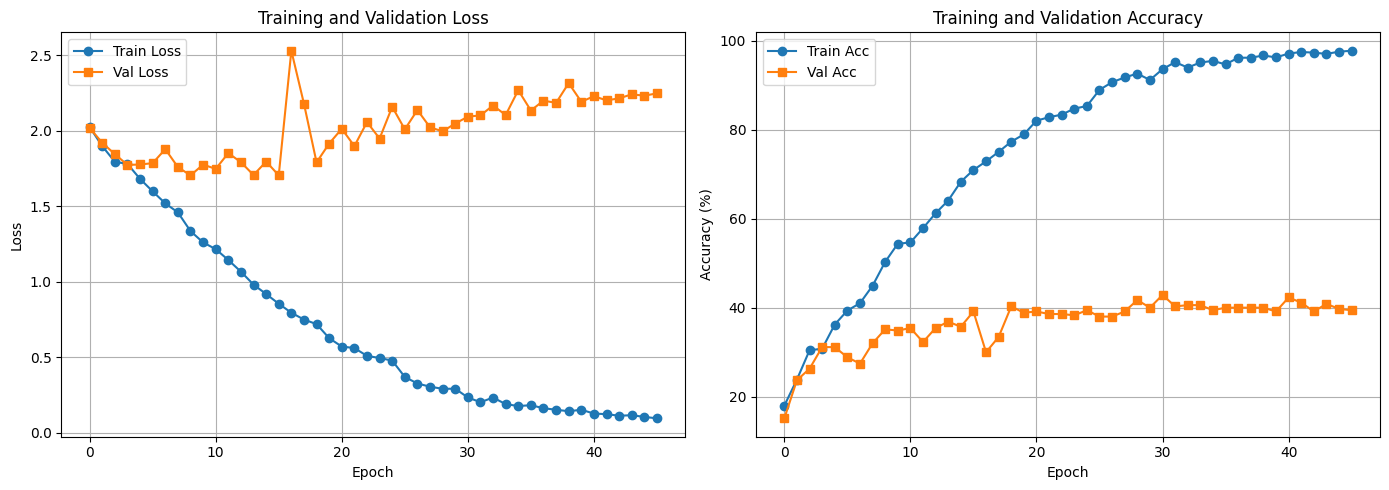

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['val_loss'], label='Val Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history['train_acc'], label='Train Acc', marker='o')
ax2.plot(history['val_acc'], label='Val Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Ładuję najlepszy model Custom CNN ...


Testing:   0%|          | 0/6 [00:00<?, ?it/s]

Test Accuracy: 41.43%
Test F1-Score: 0.4011

Classification Report:
              precision    recall  f1-score   support

       angry       0.26      0.36      0.31        50
     disgust       0.41      0.18      0.25        50
        fear       0.29      0.18      0.22        50
       happy       0.52      0.60      0.56        50
     neutral       0.35      0.52      0.42        50
         sad       0.37      0.32      0.34        50
    surprise       0.69      0.74      0.71        50

    accuracy                           0.41       350
   macro avg       0.41      0.41      0.40       350
weighted avg       0.41      0.41      0.40       350



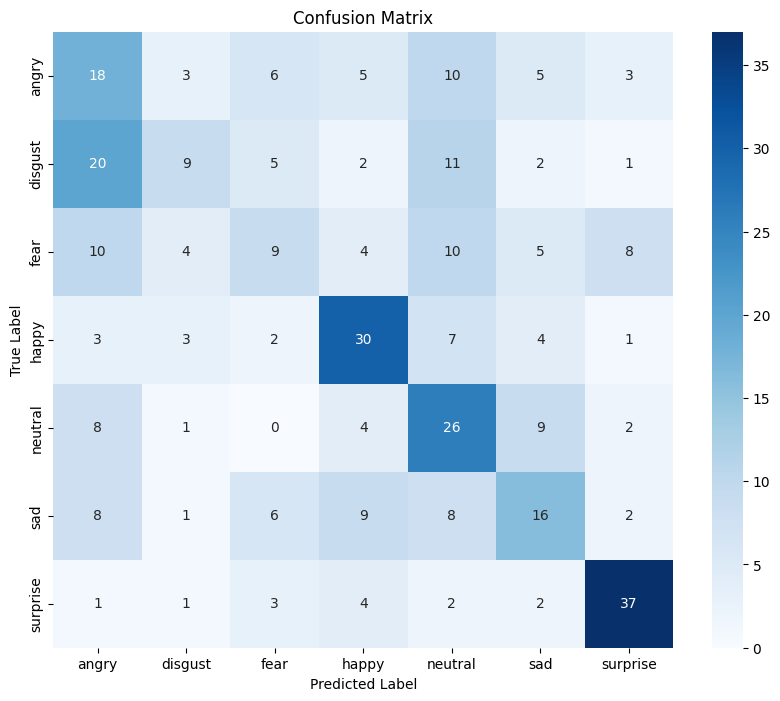

In [17]:

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

def evaluate_model(model, loader, device, classes):
    """
    Ewaluacja modelu na podanym zbiorze danych

    Przeprowadza pełną ocenę modelu z obliczeniem metryk (accuracy, F1-score),
    wygenerowaniem raportu klasyfikacji oraz wizualizacją macierzy pomyłek
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Testing"):
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Obliczanie metryk

    acc = 100. * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Test Accuracy: {acc:.2f}%")
    print(f"Test F1-Score: {f1:.4f}\n")

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    return acc, f1, all_preds, all_labels

print("Ładuję najlepszy model Custom CNN ...")
model.load_state_dict(torch.load('/content/drive/MyDrive/emotion-recognition-classifier/best_simple_cnn.pth'))
custom_acc, custom_f1, _, _ = evaluate_model(model, test_loader, DEVICE, classes)




In [19]:
import torch
import torch.nn as nn
import torchvision.models as models


class ResNetEmotionClassifier(nn.Module):
    """
    Klasyfikator emocji oparty na pretrenowanym ResNet-50

    Wykorzystuje transfer learning - model wytrenowany na ImageNet
    jest adaptowany do klasyfikacji 7 emocji poprzez wymianę ostatniej
    warstwy klasyfikującej
    """
    def __init__(self, num_classes, freeze_backbone=False):
        super().__init__()

        # Załadowanie pretrenowanego ResNet-50
        self.resnet = models.resnet50(pretrained=True)

        # Zamrożenie tylko wczesnych warstw
        if freeze_backbone:
            layers_to_freeze = [
                self.resnet.conv1,
                self.resnet.bn1,
                self.resnet.layer1,
                self.resnet.layer2
            ]
            for layer in layers_to_freeze:
                for param in layer.parameters():
                    param.requires_grad = False

        # Zamiana ostatniej warstwy FC
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)


# Inicjalizacja modelu
resnet_model = ResNetEmotionClassifier(
    num_classes=len(classes),
    freeze_backbone=False
).to(DEVICE)

print("ResNet-50 załadowany (fine-tuning enabled)")

# Policzenie parametrów
total_resnet_params = sum(p.numel() for p in resnet_model.parameters())
trainable_resnet_params = sum(
    p.numel() for p in resnet_model.parameters() if p.requires_grad
)

print(f"Całkowite parametry: {total_resnet_params:,}")
print(f"Trenowalne parametry: {trainable_resnet_params:,}")


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


ResNet-50 załadowany (fine-tuning enabled)
Całkowite parametry: 24,561,735
Trenowalne parametry: 24,561,735


In [21]:
# Przygotowanie optymalizatora, schedulera i przeprowadzenie procesu uczenia
# modelu z transfer learning na zbiorze danych emocji z ulepszonymi hiperparametrami

resnet_optimizer = optim.AdamW(resnet_model.parameters(), lr=2e-4,  weight_decay=1e-4)  # Zwiększony LR
# ReduceLROnPlateau - automatyczne zmniejszanie learning rate gdy nie ma postępu
# Pozwala modelowi "dopracować" szczegóły przy niższym LR
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, mode='max', factor=0.5, patience=5)  # Mode 'max' dla accuracy

resnet_history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_resnet_val = 0.0
resnet_early_stopping_patience = 15
resnet_epochs_without_improvement = 0

RESNET_EPOCHS = 50  # Zwiększona liczba epok

print("\n Trening ResNet-50 z ulepszonymi hiperparametrami...")
print(f" Liczba epok: {RESNET_EPOCHS}")
print(f" Learning rate: {resnet_optimizer.param_groups[0]['lr']}")
print(f" Early stopping patience: {resnet_early_stopping_patience}")

for epoch in range(RESNET_EPOCHS):
    print(f"\nEpoch {epoch+1}/{RESNET_EPOCHS}")
    current_lr = resnet_optimizer.param_groups[0]['lr']
    print(f"Learning rate: {current_lr:.6f}")

    train_loss, train_acc = train_epoch(resnet_model, train_loader, criterion, resnet_optimizer, DEVICE)
    val_loss, val_acc = validate(resnet_model, val_loader, criterion, DEVICE)

    resnet_scheduler.step(val_acc)  # Używamy accuracy zamiast loss

    resnet_history['train_loss'].append(train_loss)
    resnet_history['train_acc'].append(train_acc)
    resnet_history['val_loss'].append(val_loss)
    resnet_history['val_acc'].append(val_acc)

    print(f"✓ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"✓ Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_acc > best_resnet_val:
        best_resnet_val = val_acc
        resnet_epochs_without_improvement = 0
        torch.save(resnet_model.state_dict(), '/content/drive/MyDrive/emotion-recognition-classifier/best_resnet50.pth')
        print(f"⭐ Zapisano najlepszy ResNet (Val Acc: {val_acc:.2f}%)")
    else:
        resnet_epochs_without_improvement += 1
        print(f"   Epok bez poprawy: {resnet_epochs_without_improvement}/{resnet_early_stopping_patience}")

    # Early stopping
    if resnet_epochs_without_improvement >= resnet_early_stopping_patience:
        print(f"\n⚠️ Early stopping aktywowany! Brak poprawy przez {resnet_early_stopping_patience} epok.")
        print(f"   Najlepsza Val Acc: {best_resnet_val:.2f}%")
        break

print(f"\n{'='*60}")
print(f"✅ ResNet trening zakończony!")
print(f"{'='*60}")
print(f" Najlepsza Val Acc: {best_resnet_val:.2f}%")
print(f" Liczba epok: {len(resnet_history['train_loss'])}")


 Trening ResNet-50 z ulepszonymi hiperparametrami...
 Liczba epok: 50
 Learning rate: 0.0002
 Early stopping patience: 15

Epoch 1/50
Learning rate: 0.000200


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Train Loss: 1.9623 | Train Acc: 22.00%
✓ Val Loss: 1.9122 | Val Acc: 22.57%
⭐ Zapisano najlepszy ResNet (Val Acc: 22.57%)

Epoch 2/50
Learning rate: 0.000200


Training:   0%|          | 0/22 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Train Loss: 0.0136 | Train Acc: 99.93%
✓ Val Loss: 2.1974 | Val Acc: 38.00%
   Epok bez poprawy: 14/15

Epoch 28/50
Learning rate: 0.000025


Training:   0%|          | 0/22 [00:00<?, ?it/s]

Validation:   0%|          | 0/6 [00:00<?, ?it/s]

✓ Train Loss: 0.0126 | Train Acc: 99.93%
✓ Val Loss: 2.1812 | Val Acc: 39.71%
   Epok bez poprawy: 15/15

⚠️ Early stopping aktywowany! Brak poprawy przez 15 epok.
   Najlepsza Val Acc: 42.00%

✅ ResNet trening zakończony!
 Najlepsza Val Acc: 42.00%
 Liczba epok: 28



Ewaluacja ResNet-50 na zbiorze testowym...


Testing:   0%|          | 0/6 [00:00<?, ?it/s]

Test Accuracy: 36.00%
Test F1-Score: 0.3287

Classification Report:
              precision    recall  f1-score   support

       angry       0.27      0.44      0.33        50
     disgust       0.25      0.02      0.04        50
        fear       0.17      0.14      0.15        50
       happy       0.54      0.70      0.61        50
     neutral       0.28      0.24      0.26        50
         sad       0.25      0.28      0.26        50
    surprise       0.60      0.70      0.65        50

    accuracy                           0.36       350
   macro avg       0.34      0.36      0.33       350
weighted avg       0.34      0.36      0.33       350



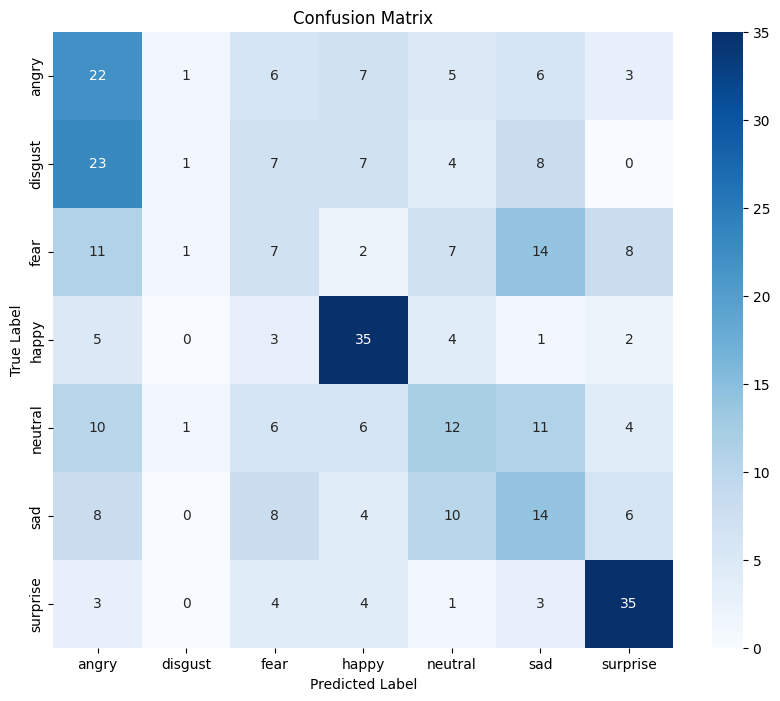

In [22]:
# Załadowanie najlepszego checkpointu modelu ResNet-50 i przeprowadzenie
# kompleksowej oceny na zbiorze testowym z wygenerowaniem metryk i wizualizacji

print("\nEwaluacja ResNet-50 na zbiorze testowym...")
resnet_model.load_state_dict(torch.load('/content/drive/MyDrive/emotion-recognition-classifier/best_resnet50.pth'))
resnet_acc, resnet_f1, _, _ = evaluate_model(resnet_model, test_loader, DEVICE, classes)



In [23]:
import torch

def add_gaussian_noise(images, mean=0, std=0.1):
    """Dodaje szum gaussowski"""
    noise = torch.randn_like(images) * std + mean
    return torch.clamp(images + noise, 0, 1)

def add_salt_pepper_noise(images, prob=0.05):
    """Dodaje szum sól i pieprz"""
    noisy = images.clone()
    salt = torch.rand_like(images) < prob/2
    pepper = torch.rand_like(images) < prob/2
    noisy[salt] = 1.0
    noisy[pepper] = 0.0
    return noisy

def add_speckle_noise(images, std=0.1):
    """Dodaje szum plamkowy"""
    noise = torch.randn_like(images) * std
    return torch.clamp(images * (1 + noise), 0, 1)

print(" Funkcje szumu zdefiniowane")

 Funkcje szumu zdefiniowane


In [24]:
# Badanie jak różne typy szumu wpływają na jakość klasyfikacji
# Symuluje realne warunki: słabe oświetlenie, kompresja JPEG, zakłócenia kamery


noise_types = {
    'Clean': lambda x: x,
    'Gaussian (σ=0.1)': lambda x: add_gaussian_noise(x, std=0.1),
    'Gaussian (σ=0.2)': lambda x: add_gaussian_noise(x, std=0.2),
    'Salt & Pepper (5%)': lambda x: add_salt_pepper_noise(x, prob=0.05),
    'Salt & Pepper (10%)': lambda x: add_salt_pepper_noise(x, prob=0.10),
    'Speckle (σ=0.1)': lambda x: add_speckle_noise(x, std=0.1),
}

def evaluate_with_noise(model, loader, device, noise_fn):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            images = noise_fn(images)  # Dodanie szumu

            outputs = model(images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels.to(device)).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = 100. * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1


custom_results = {}
resnet_results = {}


print("Ładuję modele...")
model.load_state_dict(torch.load('/content/drive/MyDrive/emotion-recognition-classifier/best_simple_cnn.pth'))
print("✓ Custom CNN załadowany")



print("\n Testowanie odporności na szum...\n")

for noise_name, noise_fn in noise_types.items():
    print(f"Szum: {noise_name}")

    custom_acc, custom_f1 = evaluate_with_noise(model, test_loader, DEVICE, noise_fn)



    custom_results[noise_name] = {'acc': custom_acc, 'f1': custom_f1}

    print(f"  Custom CNN: Acc={custom_acc:.2f}%, F1={custom_f1:.4f}")

    print()

print(" Test odporności zakończony!")

Ładuję modele...
✓ Custom CNN załadowany

 Testowanie odporności na szum...

Szum: Clean
  Custom CNN: Acc=41.43%, F1=0.4011

Szum: Gaussian (σ=0.1)
  Custom CNN: Acc=29.43%, F1=0.2839

Szum: Gaussian (σ=0.2)
  Custom CNN: Acc=25.14%, F1=0.2394

Szum: Salt & Pepper (5%)
  Custom CNN: Acc=34.00%, F1=0.3259

Szum: Salt & Pepper (10%)
  Custom CNN: Acc=29.71%, F1=0.2845

Szum: Speckle (σ=0.1)
  Custom CNN: Acc=30.86%, F1=0.3040

 Test odporności zakończony!


Augumentacja disgust w zbiorze treningowym